# Liquid-bearing cloud hours by LWP and surface class

Loads the ERA5 archive **once**, then draws each figure from that in-memory
state. The load cell is the only slow step -- `open_mfdataset` over the whole
region takes minutes -- and it only has to run again if you change the region,
season, years, or thresholds. Re-running a figure cell costs a second.

Everything here comes from `plot_lwp_histogram_by_surface_class.py` -- this
notebook holds no analysis code of its own, so the two cannot drift apart.
Editing the module and re-running a figure cell picks up the change
(autoreload is on).

| Cell | What it does |
|---|---|
| Load | `prepare()` -> an `Analysis` holding the surface classification, both bin scales, and all four phase categories |
| Report | the numeric summary the command line prints |
| Figure 1 | linear LWP bins |
| Figure 2 | log-spaced LWP bins |
| Figure 3 | monthly phase occupancy, one panel per month |

Both figures are drawn from the same accumulated cell-hours; only the bin
edges differ, so their bar totals agree exactly.

## Setup

In [7]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_lwp_histogram_by_surface_class as lwph

# open_mfdataset warns about join/compat defaults changing; the module pins
# both explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use --dpi

# Set to a directory to write PNGs as well as display them; None displays only.
# SAVE_DIR = None
SAVE_DIR = Path("figures")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load the data

The slow cell. `prepare()` takes the same options as the command line, by
keyword -- `region`, `years`, `season_start`, `season_end`,
`liquid_lwp_min`, `liquid_iwp_max`, `mixed_lwp_min`, `mixed_iwp_min`,
`lwp_max_ice`, `min_cloud_fraction`, `min_season_coverage`, `lwp_lin_max`,
`lwp_lin_bins`, `lwp_log_min`, `lwp_log_max`, `lwp_log_bins`, `y_scale`,
`layout`, `storage`, `data_root`, `block_hours`, `dpi`.

Anything you leave out keeps its command-line default. Both bin scales are
accumulated here regardless of `bin_scale`, so either figure below is free.

### The four phase thresholds

The two drawn categories have **independent** thresholds, because they answer
different questions:

```
liquid only   LWP > liquid_lwp_min   and   IWP < liquid_iwp_max
mixed phase   LWP > mixed_lwp_min    and   IWP > mixed_iwp_min
```

"Liquid only" claims a radiatively liquid deck, so it wants a *high* liquid
floor and a *low* ice ceiling. "Mixed phase" only claims both species are
present, so a low floor on each is right.

**One constraint:** `liquid_iwp_max <= mixed_iwp_min`, or the two categories
overlap and hours get counted twice. `prepare()` raises a `ValueError` that
explains the violation rather than producing a quietly wrong figure. Note the
LWP floors cannot separate the categories -- LWP is unbounded above, so the
split rests on the IWP axis alone.

The two categories are deliberately **not exhaustive**. At these defaults a
cloud with 3 g m-2 of liquid and no ice is in neither: too thin for "liquid
only", too dry for "mixed". The report's `neither` column counts exactly that
population, and the four columns are checked to partition `cloudy` exactly.

In [8]:
A = lwph.prepare(
    region="barrow",
    years=tuple(range(2022, 2026)),   # season START years
    season_start=(10, 1),
    season_end=(3, 31),

    # Liquid only: a substantial liquid deck with ice near enough to absent.
    liquid_lwp_min=5.0,               # g m-2, LWP must exceed
    liquid_iwp_max=5.0,               # g m-2, IWP must stay below

    # Mixed phase: both species merely have to be present.
    mixed_lwp_min=5.0,                # g m-2, LWP must exceed
    mixed_iwp_min=5.0,                # g m-2, IWP must exceed

    min_cloud_fraction=0.99,                         # overcast only
    lsm_tol = 0.01,                                 # land-sea mask tolerance for 
                                                    # classifying a grid cell as land or sea
    open_ocean_max_siconc = 0.05,                       # maximum sea ice concentration for a grid cell to be
                                                    # considered open ocean
    sea_ice_min_siconc = 0.95,                          # minimum sea ice concentration for a grid cell to be
                                                    # considered sea ice,           
    
    storage="local",
    dpi=350,
)

Liquid-bearing cloud hours by LWP and surface class
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 107,856 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.99
  Liquid only: LWP > 5 and IWP < 5  (g m-2)
  Mixed phase: LWP > 5 and IWP > 5  (g m-2)
  LWP bins   : linear 0-600 in 24 | log 5-1000 in 12

  Seasons found (18), coverage of the 183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001:  99.5%
    2001/2002:  50.3%   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013:  99.5%
    2013/2014:  99.5%
    2014/2015:  99.5%
    2015/2016: 100.0%
    2016/2017:  99.5%
    2017/2018:  93.4%
    2018/2019:  99.5%
    2019/2020: 100.0%
    2020/2021:  99.5%
    2021/2022:  99.5%
    2022/2023:  99.5%
    2023/2024: 100.0%
    2024/2025:  99.5%
    2025/202

## Numeric report

Hours per season per grid cell in each surface class, split into `liquid`,
`mixed`, `ice` and `neither` -- which partition the overcast hours exactly,
with the residual printed as a check. Also the interannual spread and which
surface class the Utqiagvik cell falls in. Optional; the figures do not
depend on it.

In [9]:
lwph.print_report(A)


  Hours per season per grid cell (4,392 h in the window), mean over 4 season(s):
    class                   area %   cloudy   liquid    mixed      ice  neither  liq+mix %   med LWP
    -------------------------------------------------------------------------------------------------
    Land                      0.69     1788       90      795      218      686       49.5      30.9
    Coastal (mixed)          11.66     2018      140      889      180      810       51.0      32.6
    Open ocean                8.94     2508      258     2023        6      220       91.0      84.7
    Marginal ice zone        15.22     3010      450     1662      110      788       70.2      34.6
    Sea ice                  63.50     2608      268      660      314     1366       35.6      20.3
    Utqiagvik (ARM site)    1 cell     2195      203      968      160      864       53.4      34.9
    -------------------------------------------------------------------------------------------------
    liq

## Figures

Each cell is self-contained: it reads `A` and returns a `matplotlib` figure.
Pass `out_dir=` to save. Nothing below re-reads the archive.

### 1. Linear LWP bins

Equal-width bins from 0 to `lwp_lin_max`. The physical-axis copy, directly
comparable to a linear-axis histogram from a ground site. The rightmost bar is
the overflow.

  -> figures/barrow_lwp_hist_surfaceclass_linear_mean2022-2025.png


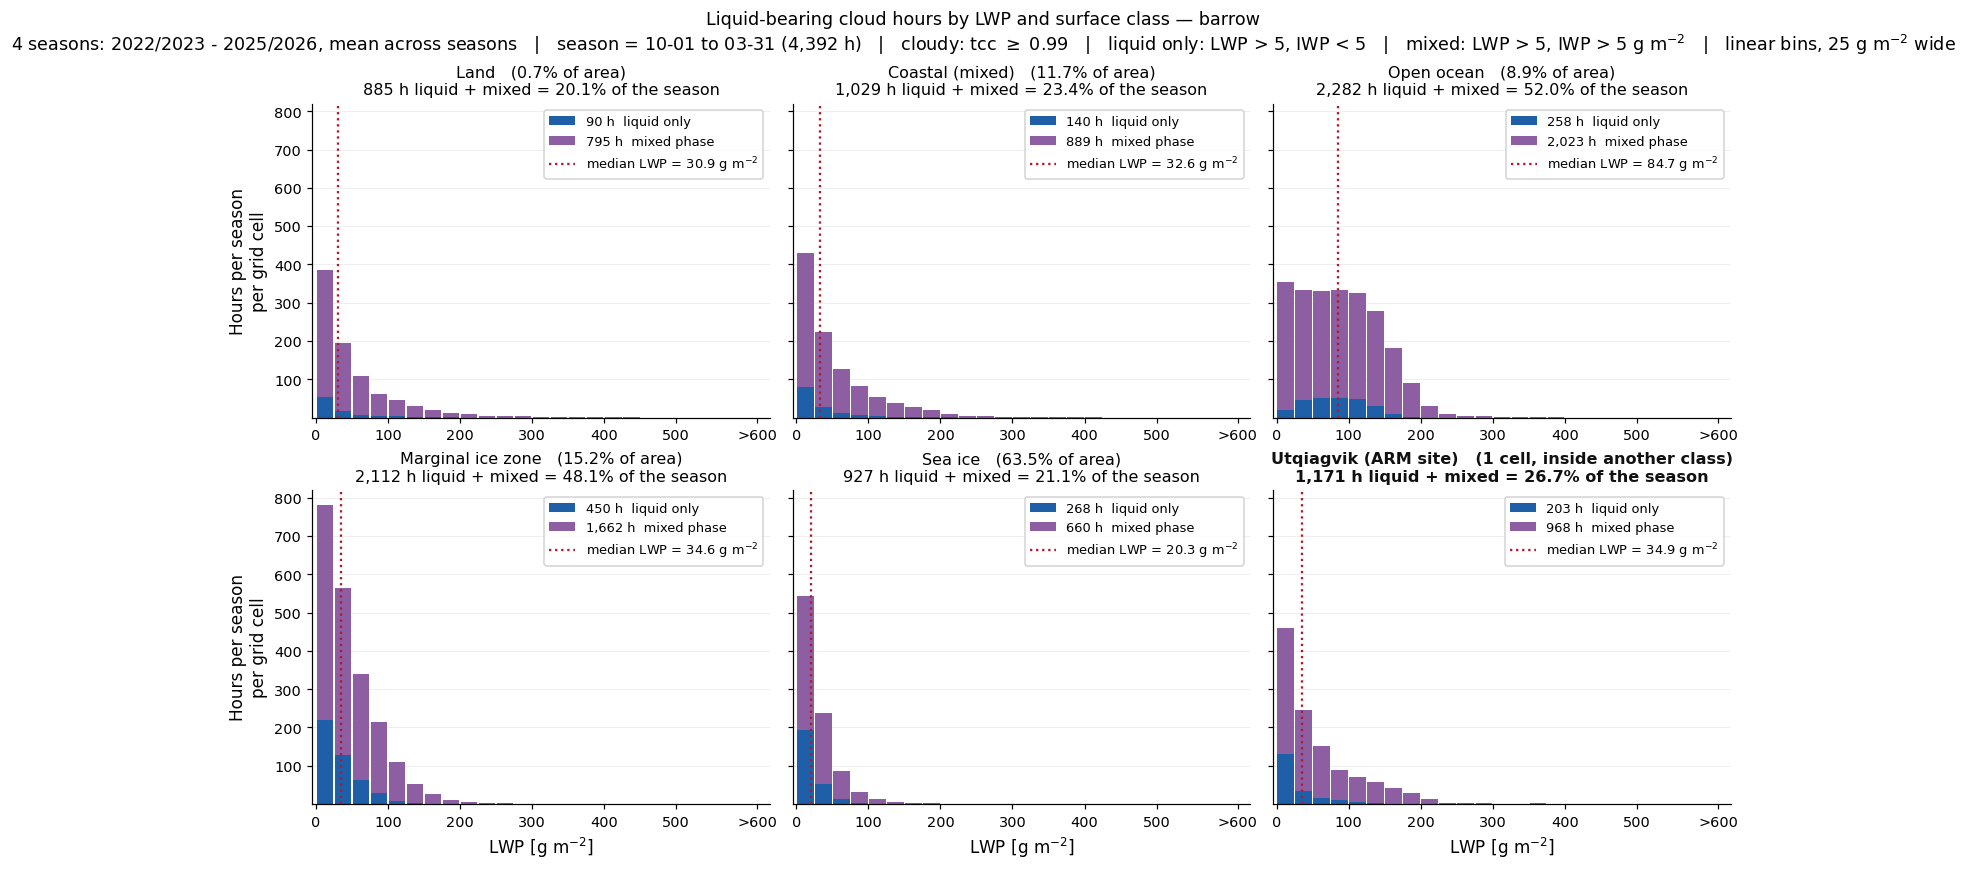

In [10]:
lwph.fig_linear(A, out_dir=SAVE_DIR);

### 2. Log-spaced LWP bins

The same hours over log-spaced bins, which resolves the low-LWP end where the
midwinter population lives. Leftmost bar is the underflow, rightmost the
overflow, so nothing is dropped relative to figure 1.

  -> figures/barrow_lwp_hist_surfaceclass_log_mean2022-2025.png


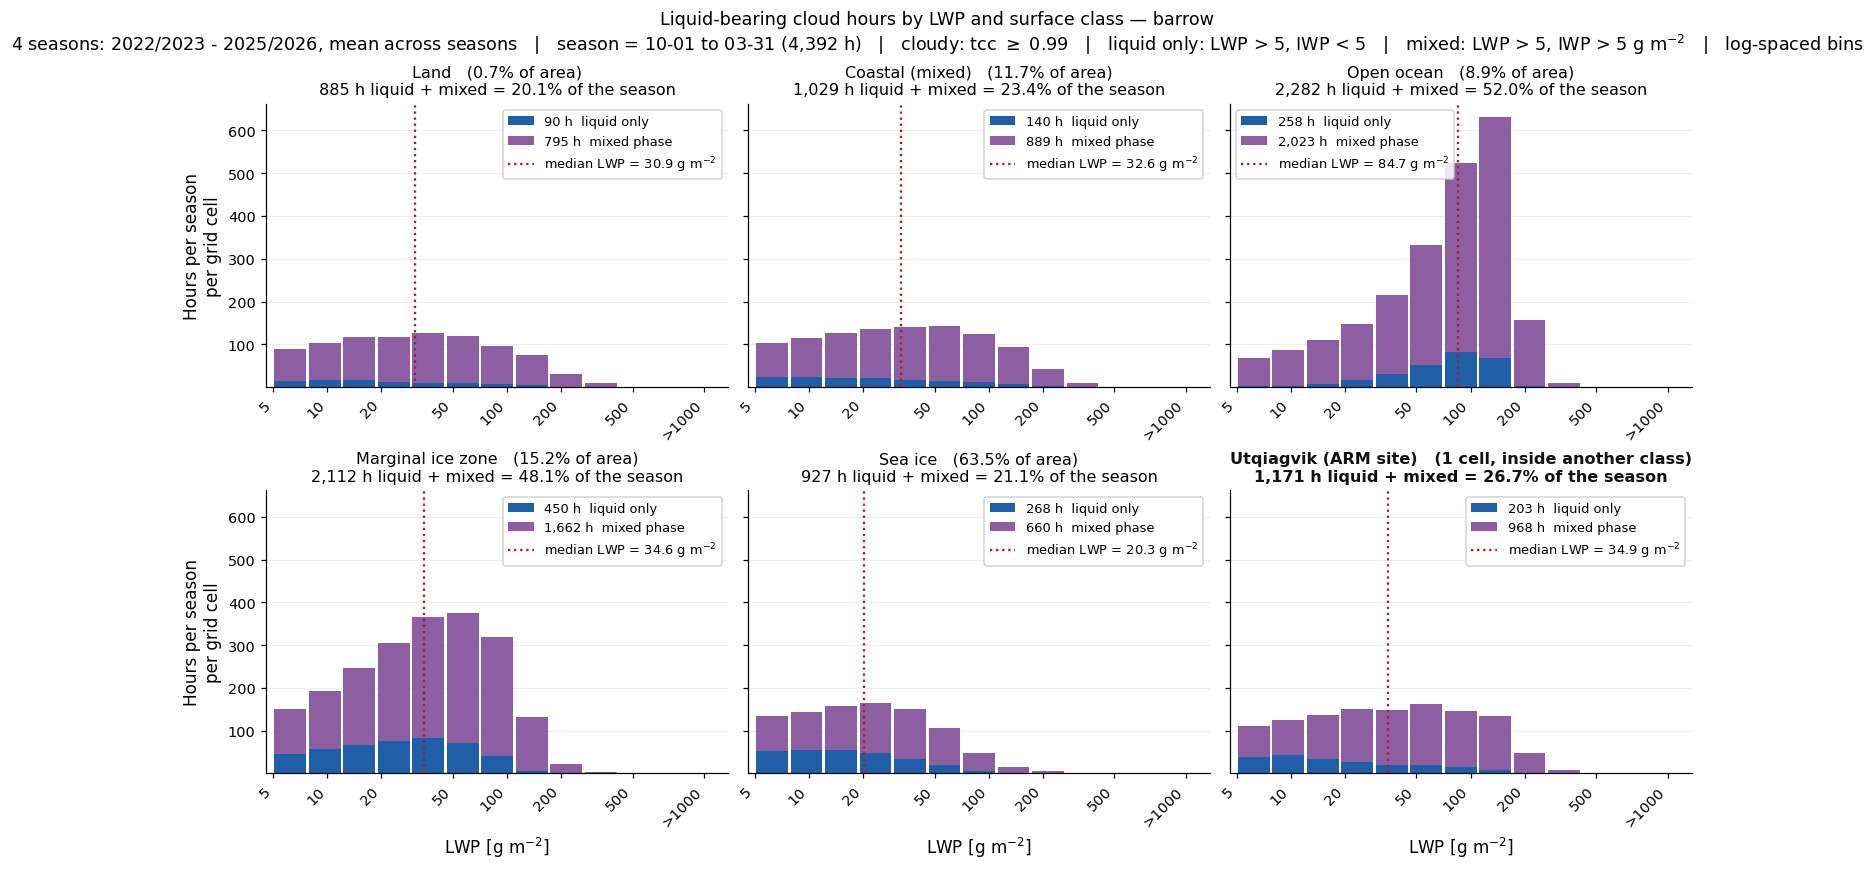

In [11]:
lwph.fig_log(A, out_dir=SAVE_DIR);

### 3. Monthly cloud-phase occupancy

One panel per month, three bars each: the share of that month's cell-hours
spent under a **liquid-only**, **ice-only**, or **mixed-phase** cloud, using
the same thresholds set in the load cell. Averaged over the seasons, with
whiskers spanning the min-max across them.

The panel grid follows the season window: **2 x 3** for an Oct-Mar season,
**2 x 4** for Aug-Mar.

The three bars do **not** sum to 100%. They are three of the four categories
that partition the overcast hours -- the fourth is the `neither` column from
the report -- and clear hours are in none of them. Each panel title states
the month's overcast share, so the remainder is accounted for.

Unlike the histogram, ice-only **is** drawn here: the x axis is a category
rather than LWP, so an ice cloud has somewhere to sit, and its rise through
the winter is much of the point.

  -> figures/barrow_monthly_phase_fraction_all_mean2022-2025.png


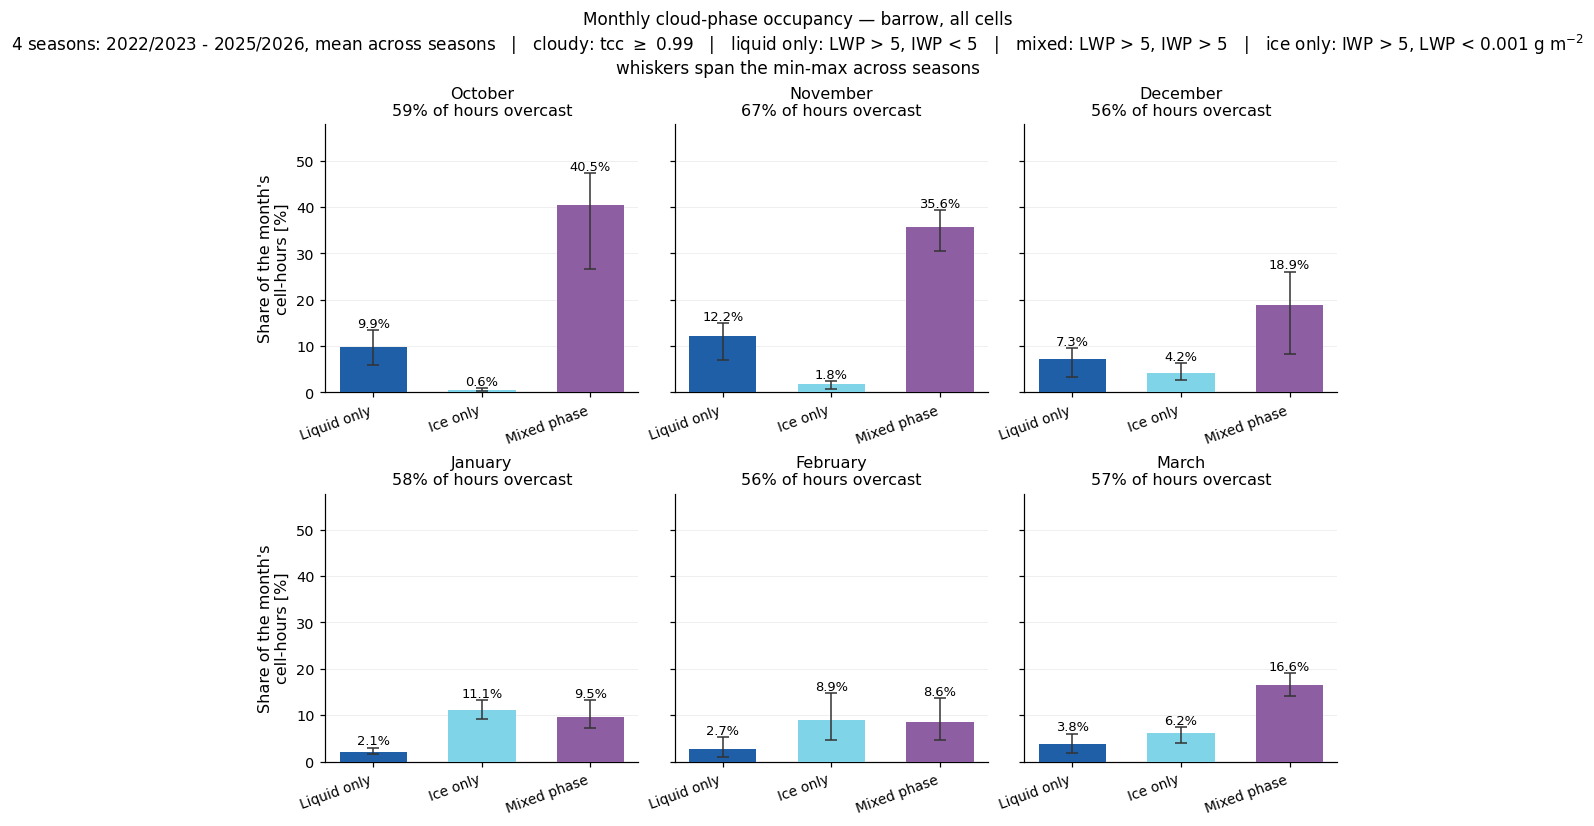

In [12]:
lwph.fig_monthly_phase_fraction(A, out_dir=SAVE_DIR);

#### The same, restricted to one surface class

`surface_class` picks which cells are averaged: `None`/`"all"` for the whole
domain (the default above), any name from `CLASS_ORDER`, or `"arm_site"` for
the single Utqiagvik grid cell. No reload -- it reads the same `A`.

  -> figures/barrow_monthly_phase_fraction_open_ocean_mean2022-2025.png
  -> figures/barrow_monthly_phase_fraction_sea_ice_mean2022-2025.png
  -> figures/barrow_monthly_phase_fraction_arm_site_mean2022-2025.png


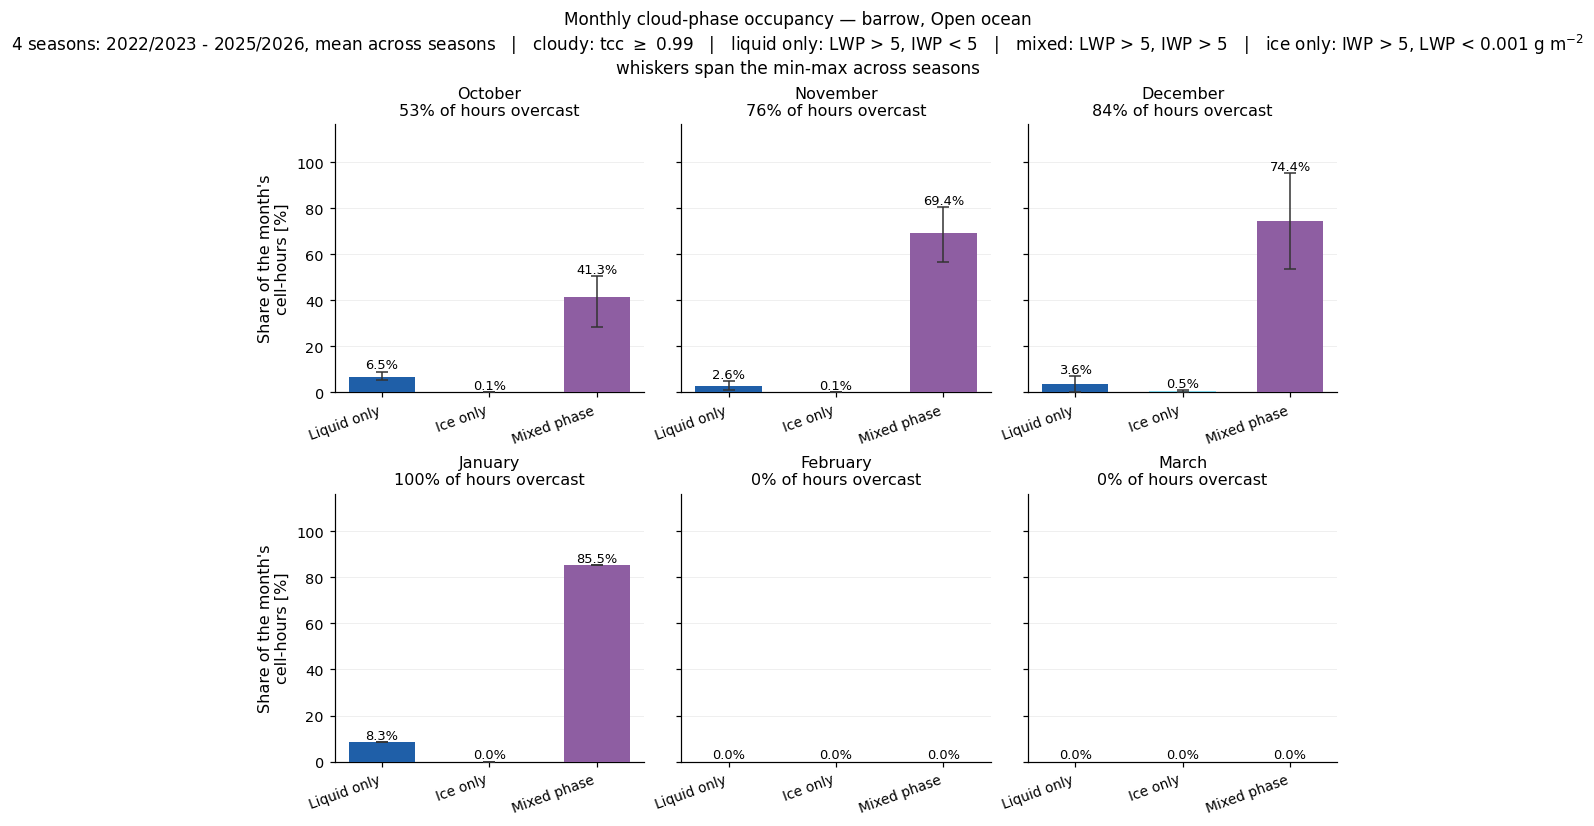

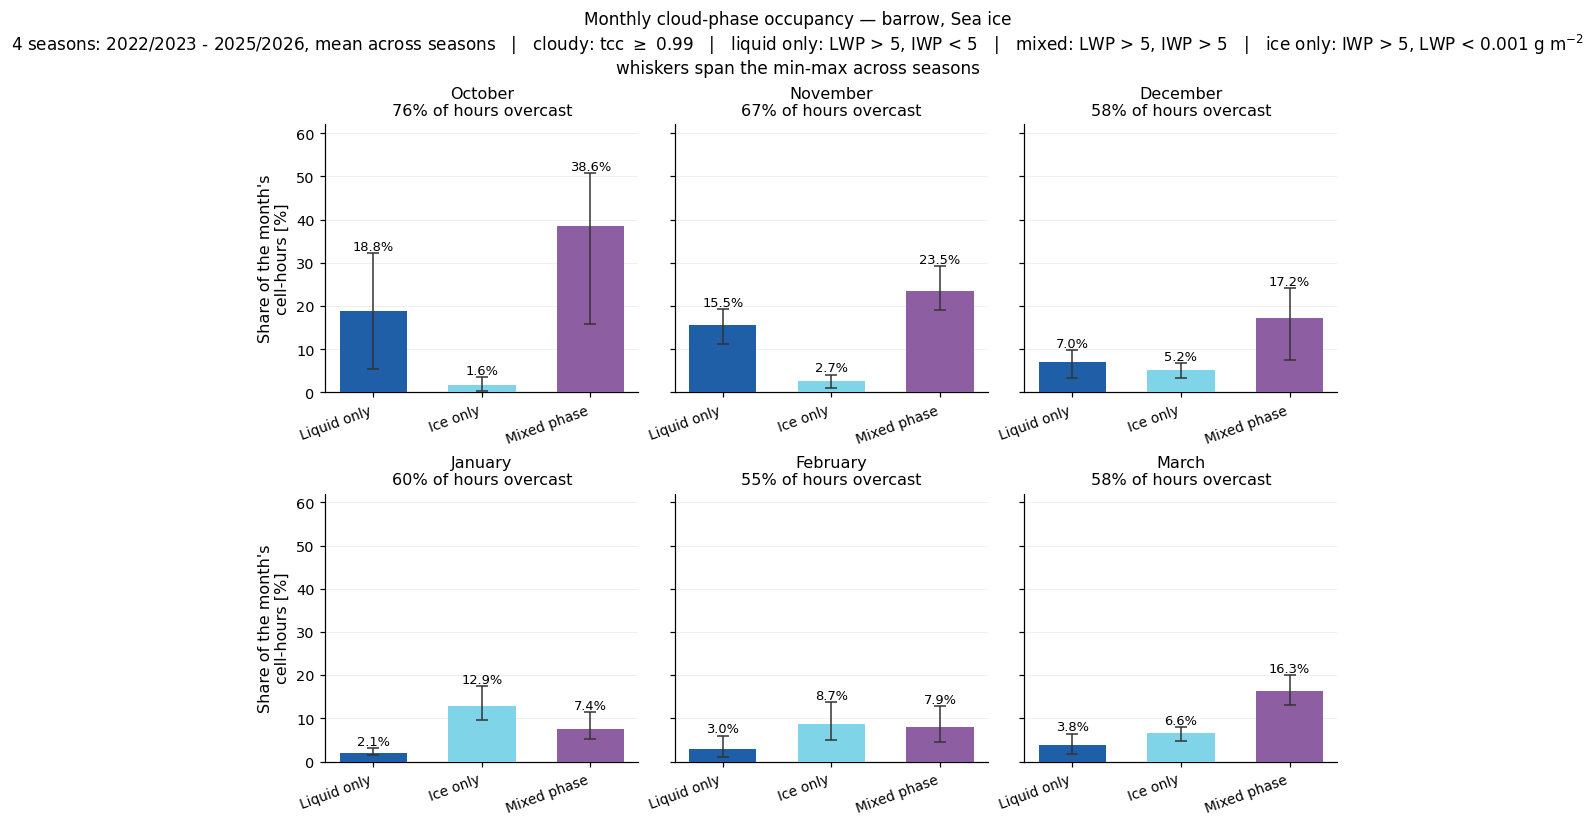

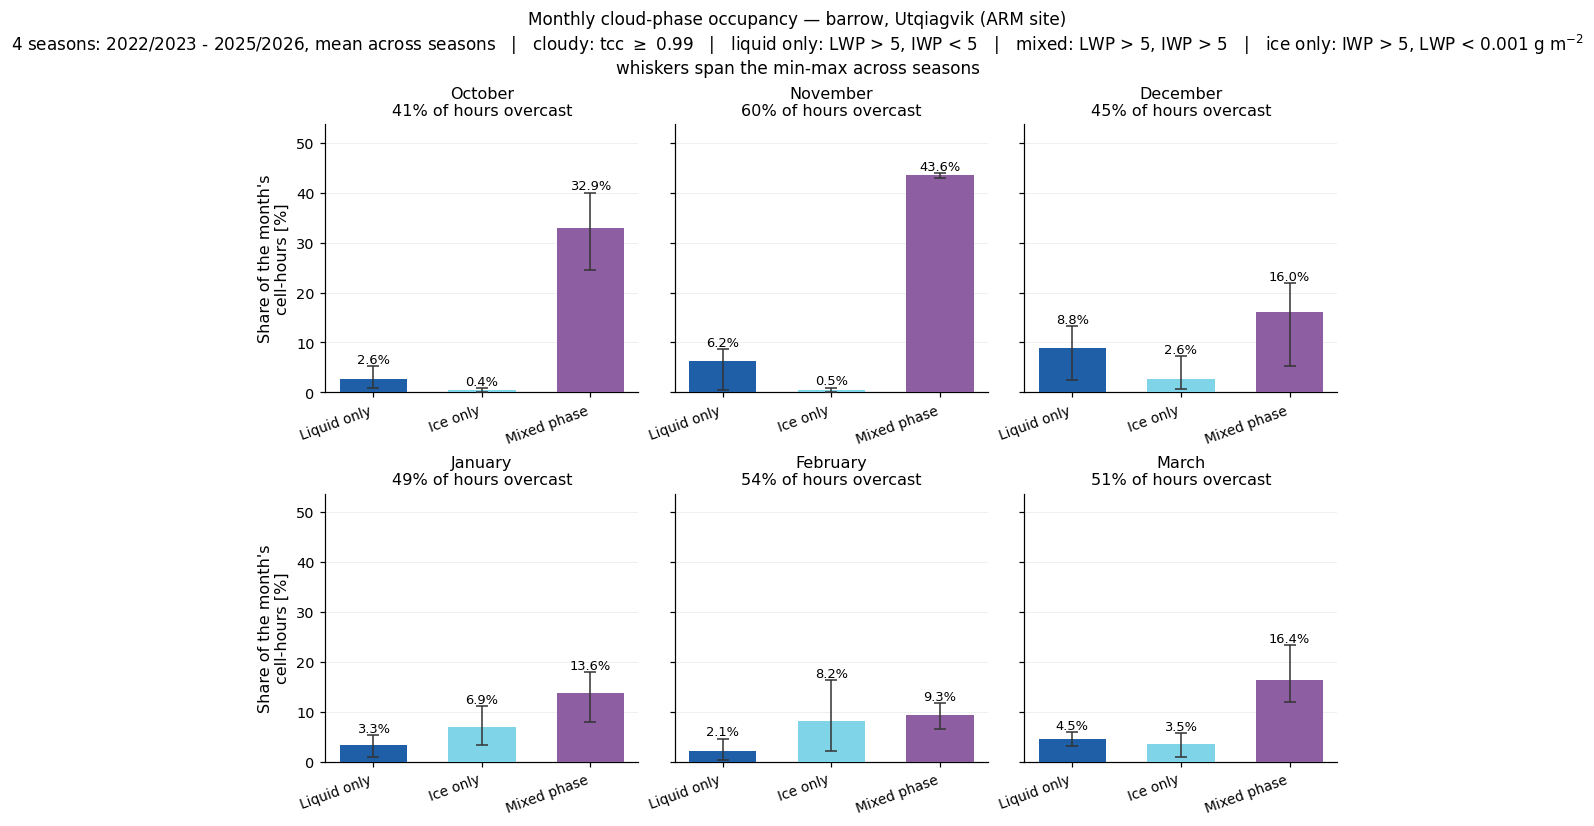

In [13]:
for sc in ("open_ocean", "sea_ice", "arm_site"):
    lwph.fig_monthly_phase_fraction(A, surface_class=sc, out_dir=SAVE_DIR)

## Redraw everything

Same set the command-line run writes.

  -> figures/barrow_lwp_hist_surfaceclass_linear_mean2022-2025.png
  -> figures/barrow_lwp_hist_surfaceclass_log_mean2022-2025.png
  -> figures/barrow_monthly_phase_fraction_all_mean2022-2025.png


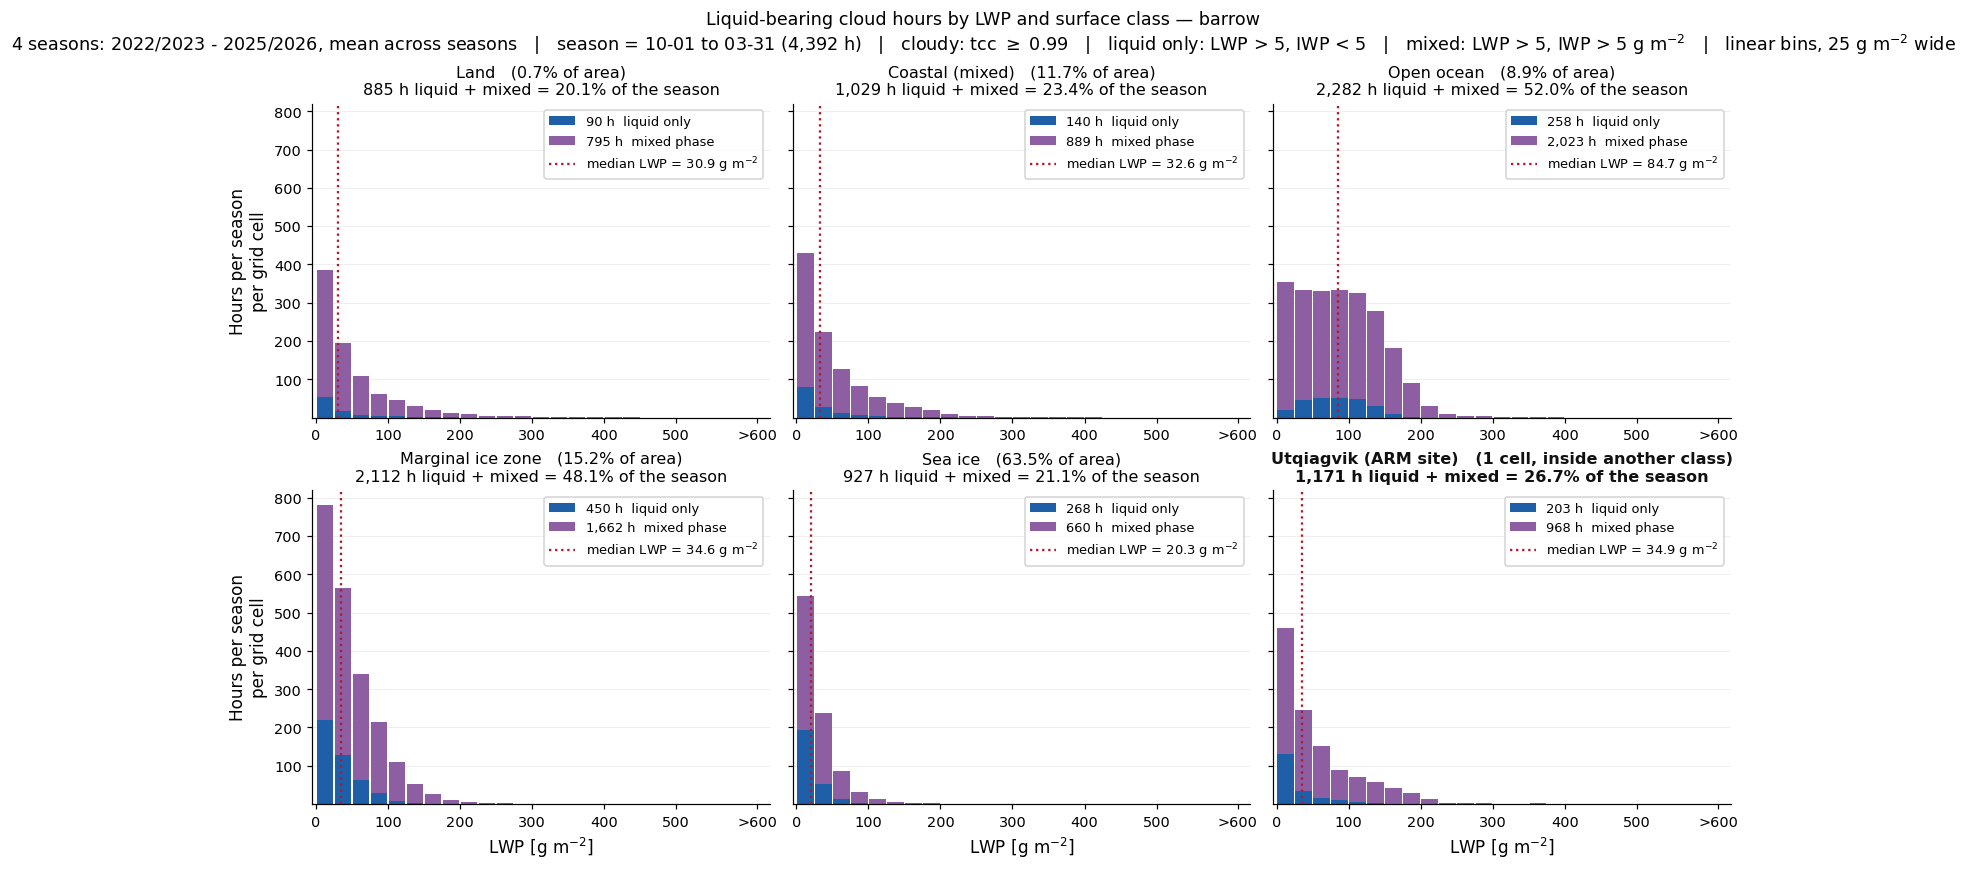

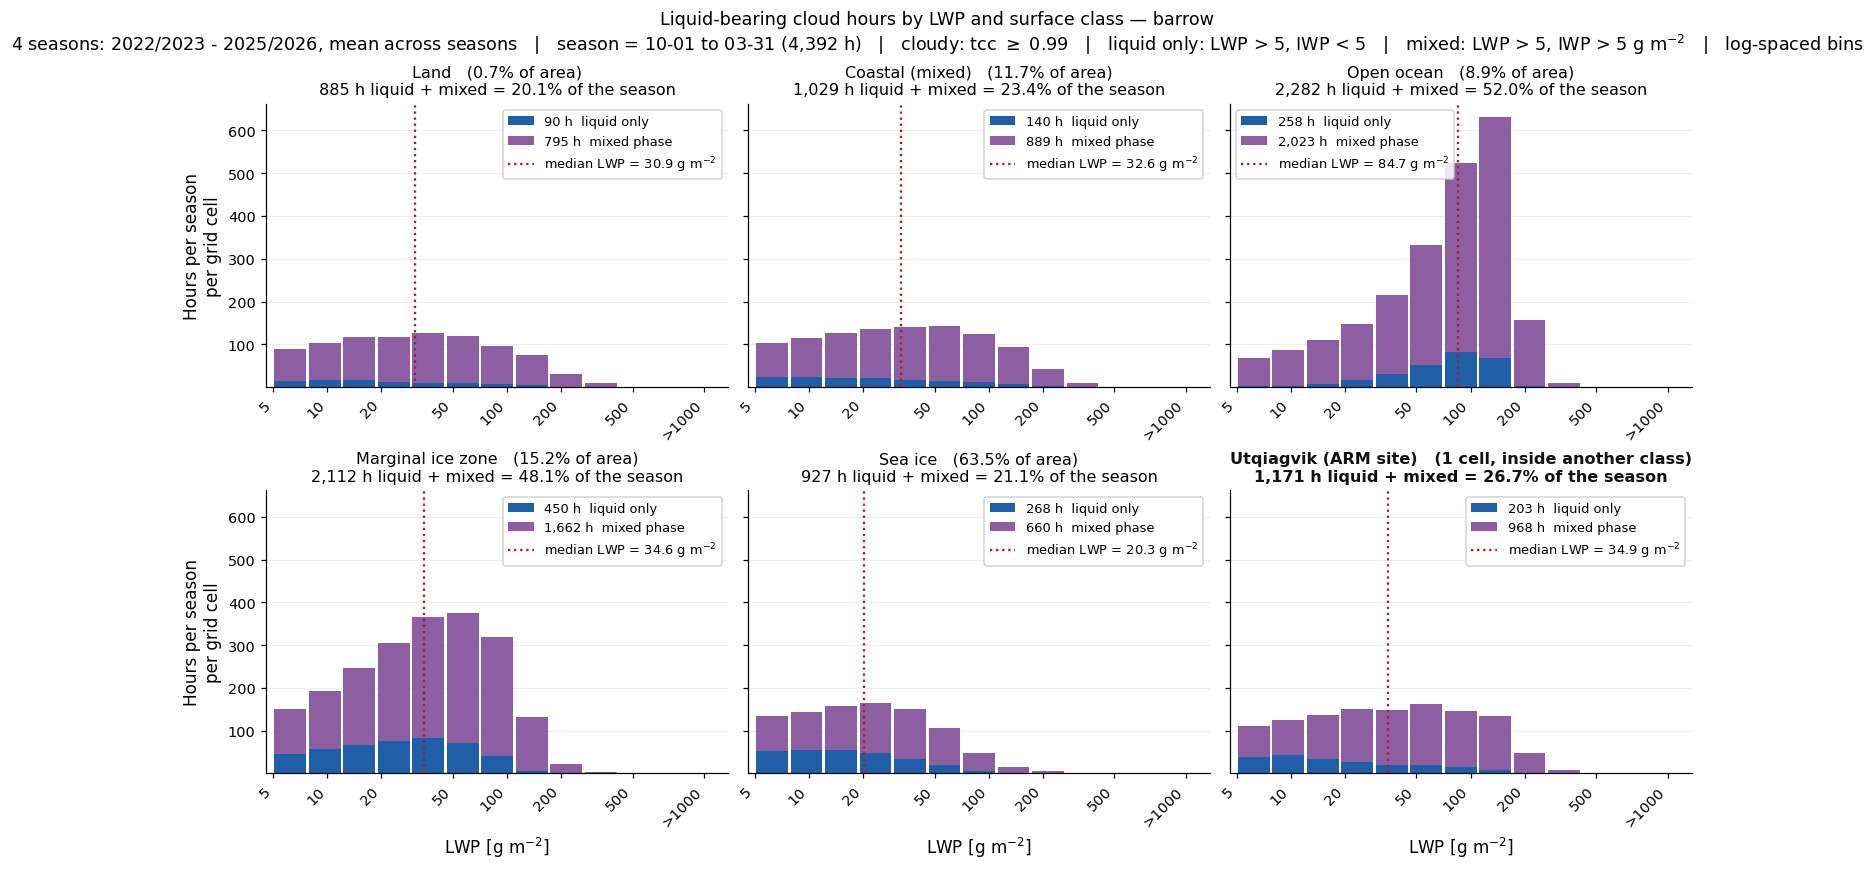

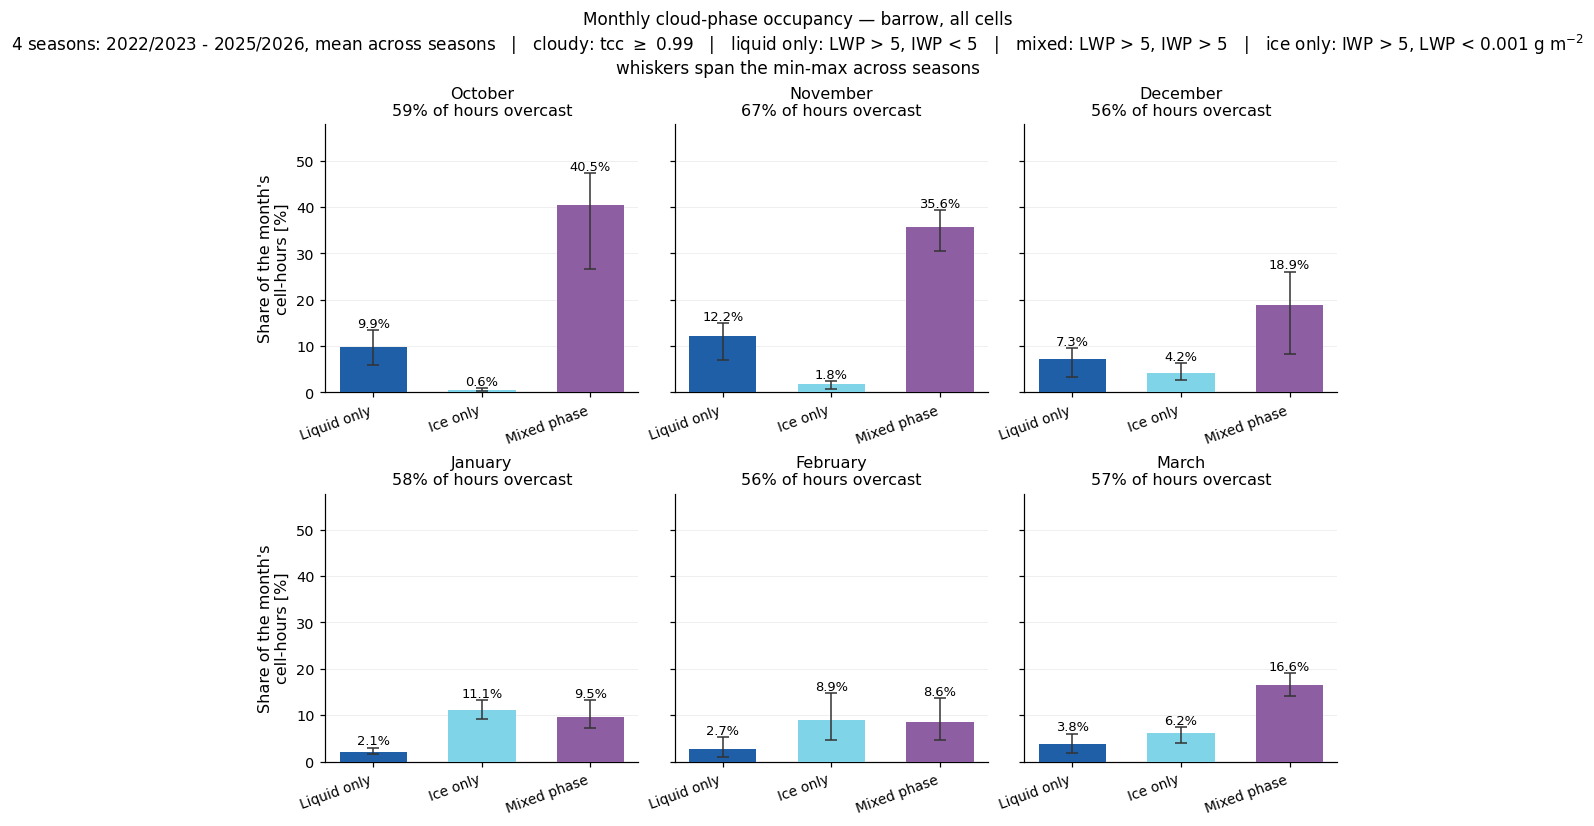

In [14]:
for fn in lwph.ALL_FIGURES:
    fn(A, out_dir=SAVE_DIR);

## Changing options

Anything that alters what is loaded, classified, or binned -- region, years,
season window, any of the four phase thresholds, cloud-cover gate, bin edges
-- needs a fresh `prepare()`, because the histograms are accumulated during
the streaming pass:

```python
# stricter 'liquid only': a thicker deck, and even less ice allowed
A_strict = lwph.prepare(region="barrow", years=(2019, 2020),
                        liquid_lwp_min=25.0, liquid_iwp_max=0.5,
                        mixed_lwp_min=1.0, mixed_iwp_min=1.0)
lwph.fig_log(A_strict)

# no gap at all: every cloud with LWP > 1 lands in one category or the other
A_tight = lwph.prepare(region="barrow", years=(2019, 2020),
                       liquid_lwp_min=1.0, liquid_iwp_max=1.0,
                       mixed_lwp_min=1.0, mixed_iwp_min=1.0)
lwph.fig_linear(A_tight)

# midwinter only
A_djf = lwph.prepare(region="barrow", years=(2019, 2020),
                     season_start=(12, 1), season_end=(2, 28))
lwph.fig_linear(A_djf)
```

Options that only affect DRAWING can be changed on the existing `A` without
reloading, since the figures read them at draw time:

```python
A.args.y_scale = "log"      # hours axis, for the high-LWP tail
lwph.fig_linear(A)

A.args.layout = (3, 2)
lwph.fig_log(A)
```

Note `bin_scale` is a command-line convenience only: `prepare()` fills both
scales either way, so in a notebook just call the figure you want.